In [2]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import argparse
import yaml
from types import SimpleNamespace

sys.path.append('/workspace/sdb1/img2fmri/SynBrain/src')
sys.path.append('/workspace/sdb1/img2fmri/SynBrain/src/vae')

from brainvae import BrainVAE
from utils import evaluate_fmri_reconstruction, seed_everything
from dataset import multisub_clip_dataset

/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
2026-01-07 14:27:22.052937: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-07 14:27:22.100756: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-07 14:27:23.224776: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find T

In [3]:
# Config setup simulating argparse
args = SimpleNamespace(
    seed=1024,
    batch_size=32,
    local_batch_size=32,
    num_epochs=50,
    model_name="vae-nsd-s1-vs1-bs24-350",
    subject="[1]",
    valid_sub=1,
    unseen_sub=9,
    hour=36,
    save_path="/workspace/sdb1/img2fmri/BrainSyn",
    data_path="/workspace/sdb1/img2fmri/NSD/data/nsd",
    clip_weight=1000,
    kl_weight=0.001,
    base_lr=1e-4,
    linear_dim=2048,
    wandb_log=False,
    ckpt_interval=1
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
seed_everything(args.seed)

Using device: cuda


In [4]:
# Load Model
def load_config(config_file):
    with open(config_file, "r") as file:
        return yaml.safe_load(file)

config = load_config("/workspace/sdb1/img2fmri/SynBrain/configs/brainvae.yaml")
model_config = config["model"]["params"]
ddconfig = model_config["ddconfig"]

model = BrainVAE(ddconfig=ddconfig,
                    clip_weight=args.clip_weight,
                    kl_weight=args.kl_weight,
                    hidden_dim=1024,
                    linear_dim=2048,
                    embed_dim=1664
                    )

model.to(device)

# Load Checkpoint
ckpt_path = f'{args.save_path}/train_logs/{args.model_name}/last.pth'
if os.path.exists(ckpt_path):
    print(f"Loading checkpoint from {ckpt_path}")
    checkpoint = torch.load(ckpt_path, map_location=device)
    
    # Handle DataParallel prefix 'module.'
    state_dict = checkpoint['model']
    new_state_dict = {}
    for k, v in state_dict.items():
        name = k.replace('module.', '') if k.startswith('module.') else k
        new_state_dict[name] = v
        
    model.load_state_dict(new_state_dict)
    print(f"Loaded model from epoch {checkpoint['epoch']}")
else:
    print(f"Checkpoint not found at {ckpt_path}")

making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 256, 128, 128) = 4194304 dimensions.
making attention of type 'vanilla' with 512 in_channels
Loading checkpoint from /workspace/sdb1/img2fmri/BrainSyn/train_logs/vae-nsd-s1-vs1-bs24-350/last.pth
Loaded model from epoch 28


In [5]:
# Load Data
train_dataloader, val_dataloader = multisub_clip_dataset(args)

16.3835 -16.384
Train Voxel Sub1: (27000, 15724)
Train Clip Sub1: (27000, 256, 1664)
16.3835 -14.257167
Valid Voxel Sub1: (1000, 15724)
Valid Clip Sub1: (1000, 256, 1664)
Training batch size: 32
Dataset samples: fmri-27000 feature-27000
Testing batch size: 300
Dataset samples: fmri-1000 feature-1000

Done with Data preparations!


Starting inference on validation set...
Validation data shape: (1000, 1, 15724)
Reconstruction data shape: (1000, 1, 15724)
总体MSE: 0.012267
总体解释方差: 0.8874


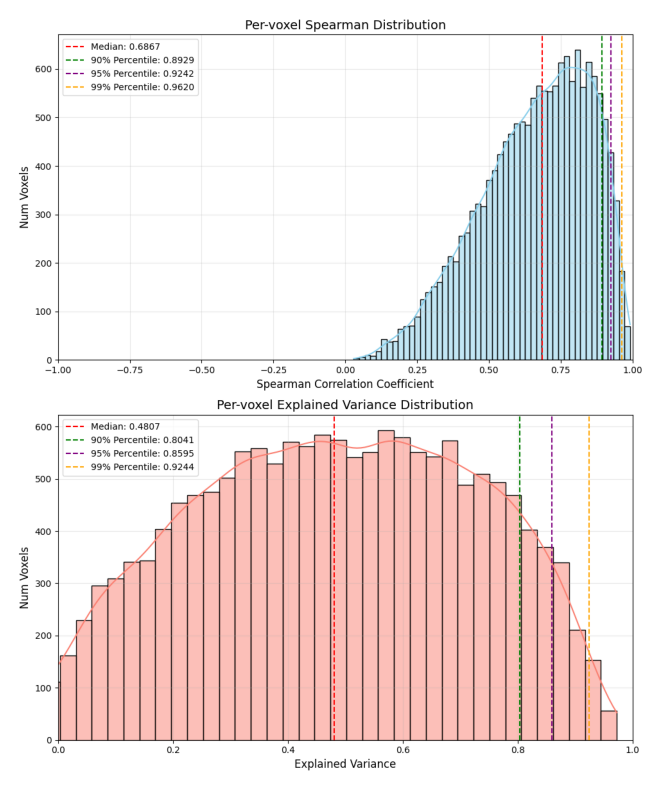

In [6]:
# Run Inference and Evaluation
model.eval()
all_val_fmri = []
all_recon_fmri = []

print("Starting inference on validation set...")
with torch.no_grad():
    for val_i, (val_fmri, val_z, val_sub) in enumerate(val_dataloader):
        val_fmri = val_fmri.unsqueeze(1).float().to(device)
        val_z = val_z.float().to(device)
        
        # The model forward returns: z, recon, recon_loss, kl_loss, clip_loss, loss
        # we only need recon
        val_zs, val_recon, _, _, _, _ = model(val_fmri, val_z, sample_posterior=False)
        
        all_val_fmri.append(val_fmri.cpu().numpy())
        all_recon_fmri.append(val_recon.cpu().numpy())

all_val_fmri = np.concatenate(all_val_fmri, axis=0)
all_recon_fmri = np.concatenate(all_recon_fmri, axis=0)

print(f"Validation data shape: {all_val_fmri.shape}")
print(f"Reconstruction data shape: {all_recon_fmri.shape}")

# Call evaluation function
pil_image = evaluate_fmri_reconstruction(all_val_fmri, all_recon_fmri)

# Display the result
plt.figure(figsize=(10, 10))
plt.imshow(pil_image)
plt.axis('off')
plt.show()